# Initialize

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
import sklearn.metrics as metrics
import random
from tqdm import tqdm

In [3]:
from torchvision.transforms import ToTensor
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights
import torch
from torch import nn
import torch.nn.functional as F

from PIL import Image, ImageOps

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
#dir = r'C:\Non-system\Course Material\M1A\STA2453\data'
dir = r'/content/drive/MyDrive/STA2453' #/content/

Load overlap.csv data as Pandas dataframe

In [6]:
# load Huron data
Huron_list = []
for d in glob.glob(os.path.join(dir+r'/HURONOverlap_csv', '*')):
    df = pd.read_csv(d)
    df['file'] = d
    Huron_list.append(df)
Huron_overlap_csv = pd.concat(Huron_list)

# load Simcoe data
Simc_list = []
for d in glob.glob(os.path.join(dir+r'/SIMCOverlap_csv', '*')):
    df = pd.read_csv(d)
    df['file'] = d
    Simc_list.append(df)
Simc_overlap_csv = pd.concat(Simc_list)

# Label lakes of data
Huron_overlap_csv['Lake'] = 'Huron'
Simc_overlap_csv['Lake'] = 'Simcoe'
print(Huron_overlap_csv.shape)
print(Simc_overlap_csv.shape)

(1051677, 102)
(1239578, 62)


Defining variables based on settings of this project

In [7]:
# class labels that we are interested in:
zooplanktons_interested = ['Calanoid_1', 'Cyclopoid_1', 'Bosmina_1', 'Herpacticoida',
                           'Chironomid', 'Chydoridae', 'Daphnia']
Simc_overlap_csv['Class_interest'] = Simc_overlap_csv['Class'].apply(
    lambda c: c if c in zooplanktons_interested else 'others'
)
Huron_overlap_csv['Class_interest'] = Huron_overlap_csv['Class'].apply(
    lambda c: c if c in zooplanktons_interested else 'others'
)

In [8]:
# categorize columns into different types:
col_Huron_only = list(set(Huron_overlap_csv.columns) - set(Simc_overlap_csv.columns))
# parameters related to the shape. Likely to be irrelevant when taking image as input
col_shape_related = ['Area..ABD.', 'Area..Filled.', 'Aspect.Ratio', 'Capture.X', 'Capture.Y',
                     'Circle.Fit', 'Circularity', 'Circularity..Hu.', 'Compactness', 'Convex.Perimeter',
                     'Convexity', 'Diameter..ABD.', 'Diameter..ESD.', 'Diameter..FD.', 'Edge.Gradient',
                     'Elongation', 'Feret.Angle.Max', 'Feret.Angle.Min', 'Fiber.Curl', 'Fiber.Straightness',
                     'Geodesic.Aspect.Ratio', 'Geodesic.Length', 'Geodesic.Thickness','Intensity', 'Length',
                     'Particles.Per.Chain', 'Perimeter', 'Roughness', 'Sigma.Intensity',
                     'Sphere.Complement', 'Sphere.Count', 'Sphere.Unknown', 'Sphere.Volume','Sum.Intensity',
                     'Symmetry', 'Transparency','Volume..ABD.', 'Volume..ESD.', 'Width']
# parameters related to devices, time, etc. Should be dropped to prevent overleading
col_irrelevant = ['Camera', 'Date', 'Elapsed.Time','Source.Image', 'Time', 'Timestamp']
# parameters that are relevant and not covered when taking image as parameter. Always kept.
col_relevant = ['Calibration.Factor']
# parameters of biovolume related data - highly missing...
col_biovolume = ['Biovolume..Cylinder.', 'Biovolume..P..Spheroid.', 'Biovolume..Sphere.']
# parameter used to connect the row to an image
col_image_connect = ['Image.File', 'Image.Height', 'Image.Width', 'Image.X', 'Image.Y', 'Source.Image', 'file']
# parameters that need more careful processing
col_others = ['Calibration.Image', 'Filter.Score', 'Original.Reference.ID',]
# parameters that are labels
col_labels = ['Class', 'Class_interest', 'Lake']
# parameters with only 1 unique value (thus useless)
col_single_valued = [c for c in col_shape_related+col_relevant if len(Huron_overlap_csv[c].value_counts())<=1]
# parameters we want to use for EDA
col_EDA = list(set(col_shape_related+col_relevant+col_labels) - set(col_Huron_only+col_single_valued))
col_model = list(set(col_shape_related+col_relevant+col_labels+col_image_connect) -
                 set(col_Huron_only+col_single_valued))
# parameters we want to use for model fitting
col_features = list(set(col_model) - set(col_labels+col_image_connect))

In [9]:
# Set device to CUDA for Pytorch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


# Functions

`find_missing`: Find image names in the column `Image.File` of overlap.csv that are not found in the directory.  
**Input:**  
* `df`: Pandas dataframe storing tabular data from overlap.csv data. Must contain columns `Lake` and `Image.File`.
* `directory`: Directory where the TIFF images and overlap.csv tabular data are stored. Default is the default directory `dir` defined in the notebook.  

**Output:**  
* `missing_loc`: A list of strings containing all the image file names not seen in the directory.

In [19]:
def find_missing(df, directory=dir):
    missing_loc = []
    for lake in df['Lake'].unique():
        for image_file in tqdm(df[df['Lake']==lake]['Image.File'].unique()):
            image_loc = directory + r'/' + \
                (r'HURON' if lake=='Huron' else r'SIMC') + \
                r'_OverlapTiffsWithPP/' + image_file
            if not os.path.exists(image_loc):
                df_groupby = df[(df['Lake']==lake)&(df['Image.File']==image_file)]
                missing_loc.append(image_file)
    return missing_loc

`read_images`: Read images in the tabular dataframe from the directory provided and store them in a numpy array.    
**Input:**  
* `df`: Pandas dataframe storing tabular data from overlap.csv data. Must contain columns `Lake`, `Image.File`, and `Class`.
* `directory`: Directory where the TIFF images and overlap.csv tabular data are stored. Default is the default directory `dir` defined in the notebook.  

**Output:**  
* `df_connect`: A dataframe mapping `Image.File` directories to indices (`Image.Idx`) of `images` array
* `images`: Numpy array storing images

In [20]:
def read_images(df, directory=dir):
    df_connect = df.groupby(
        ['Lake', 'Image.File'], as_index=False
    )['Class'].count().rename(columns={'Class': 'Image.Idx'}).copy() # create grouping
    images = [] # array to store images
    i = 0
    for lake in df_connect['Lake'].unique():
        for image_file in tqdm(df_connect[df_connect['Lake']==lake]['Image.File'].unique()):
            image_loc = directory + r'/' + \
                (r'HURON' if lake=='Huron' else r'SIMC') + \
                r'_OverlapTiffsWithPP/' + image_file
            image = ToTensor()(Image.open(image_loc).convert("L")) # convert image to grayscale
            images.append(image)
            df_connect.loc[
                (df_connect['Lake']==lake)&(df_connect['Image.File']==image_file),
                'Image.Idx'
            ] = i
            i = i + 1

    images = np.array(images)
    return df_connect, images

# Data process

Combine Simcoe and Huron dataset and subset the dataset to only include zooplanktons

In [ ]:
zooplanktons_Simc = Simc_overlap_csv[Simc_overlap_csv['Class'].isin(zooplanktons_interested)][col_model]
zooplanktons_Huron = Huron_overlap_csv[Huron_overlap_csv['Class'].isin(zooplanktons_interested)][col_model]
zooplanktons = pd.concat([zooplanktons_Huron, zooplanktons_Simc]).reset_index().reindex(sorted(col_model), axis=1)

for col in ['Image.Height', 'Image.Width', 'Image.X', 'Image.Y']:
    zooplanktons[col] = zooplanktons[col].astype(int)

zooplanktons = zooplanktons.copy()

In [ ]:
Simc_overlap_csv = []
Huron_overlap_csv = []

Find rows with missing images and remove them.

In [13]:
missing = find_missing(zooplanktons)

100%|██████████| 8138/8138 [00:46<00:00, 176.33it/s]


In [14]:
zooplanktons = zooplanktons.drop(zooplanktons[zooplanktons['Image.File'].isin(missing)].index)

In [15]:
zoo_sample = zooplanktons.copy()
minority_image_files = zooplanktons[
    zoo_sample['Class'].isin(
        ['Herpacticoida', 'Daphnia', 'Chydoridae']
    )
]['Image.File'].unique()
zoo_sample = zooplanktons[
    zooplanktons['Image.File'].isin(minority_image_files)
].copy()
print(zoo_sample.shape)

(61219, 44)


In [16]:
zoo_sample.groupby(by='Class', as_index=False)['Image.File'].count()

,Class,Image.File
0,Bosmina_1,996
1,Calanoid_1,28345
2,Chironomid,488
3,Chydoridae,199
4,Cyclopoid_1,28906
5,Daphnia,429
6,Herpacticoida,1856


In [21]:
print("number of samples in the final dataset: " + str(len(zoo_sample)))
print("number of unique image directories in the final dataset: " +
      str(len(zoo_sample['Image.File'].unique())))

number of samples in the final dataset: 61219
number of unique image directories in the final dataset: 1851


Load image data from directory.   
Note: reading images one by one is time consuming. It is good practice to save loaded images in a file and reload the new file after reading.

In [ ]:
# Load raw images
# image_subset = np.random.choice(zoo_sample['Image.File'].unique(), 2000, replace=False)
# zoo_subset = zoo_sample[zoo_sample['Image.File'].isin(image_subset)]
# df_connect, images = read_images(zoo_sample)
# np.save(dir + r'/df_connect.npy', df_connect)
# np.save(dir + r'/images.npy', images)

In [22]:
df_connect = pd.DataFrame(
    np.load(dir + r'/df_connect.npy', allow_pickle=True),
    columns=['Lake', 'Image.File', 'Image.Idx']
)
images = np.load(dir + r'/images.npy', allow_pickle=True)

In [23]:
df_connect

,Lake,Image.File,Image.Idx
0,Huron,04072021_Huron_10_2mm_Rep2_AD_000021.tif,0
1,Huron,04072021_Huron_10_2mm_Rep2_AD_000026.tif,1
2,Huron,04072021_Huron_10_2mm_Rep3_AD_000016.tif,2
3,Huron,04142021_Huron_004_2mm_Rep1_MS_000002.tif,3
4,Huron,04142021_Huron_004_2mm_Rep2_MS_000001.tif,4
...,...,...,...
1846,Simcoe,20190515_Simcoe_69_2mm_rep3_KG_000022.tif,1846
1847,Simcoe,20190515_Simcoe_69_2mm_rep3_KG_000023.tif,1847
1848,Simcoe,20190515_Simcoe_71_2mm_rep3_KG_000019.tif,1848
1849,Simcoe,20190515_Simcoe_71_2mm_rep3_KG_000028.tif,1849


In [24]:
images.shape

(1851, 1, 1920, 1200)

# Model body

## Model Define

### Dataset

In [ ]:
classes = ['Cyclopoid_1', 'Calanoid_1', 'Bosmina_1', 'Chironomid',
           'Herpacticoida', 'Daphnia', 'Chydoridae']

In [ ]:
# Dataset class
class Zooplankton_dataset(torch.utils.data.Dataset):
    def __init__(self, overlap_csv, df_image_mapping, image_tensor): #, classes):
        super(Zooplankton_dataset).__init__()

        scaler = StandardScaler()
        overlap_csv = overlap_csv.copy()
        overlap_csv[col_features] = scaler.fit_transform(overlap_csv[col_features]) # normalize
        self.overlap_csv = overlap_csv
        # maximum number of slices in an image
        self.feature_maxlen = overlap_csv.groupby(
            by='Image.File', as_index=False
        )['Class'].count()['Class'].max()
        self.images = image_tensor
        self.df_image_mapping = df_image_mapping
        self.classes = classes # np.sort(overlap_csv['Class'].unique()) #

        self.len = len(df_image_mapping)

    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        # process feature data
        row = self.df_image_mapping.iloc[idx]
        image_idx = row['Image.Idx']

        # read image
        image = self.images[image_idx] # find the image and normalize

        # read featured values and labels
        row = self.overlap_csv[self.overlap_csv['Image.File']==row['Image.File']].copy()
        features = torch.tensor(row[col_features].values.astype(np.float32))
        image_slices = torch.tensor(row[['Image.Height', 'Image.Width', 'Image.X', 'Image.Y']].values.astype(int))
        labels = row['Class']
        labels = torch.tensor([[int(label==c) for c in self.classes] for label in labels]) # one-hot

        # append numbers so that features, image_slices, and labels can stack
        features = torch.cat([features, torch.zeros((self.feature_maxlen-len(features), len(col_features)))])
        image_slices = torch.cat([image_slices, torch.zeros((self.feature_maxlen-len(image_slices), 4), dtype=torch.int8)])
        labels = torch.cat([labels, torch.zeros((self.feature_maxlen-len(labels), len(self.classes)))])

        return (image, features, image_slices, torch.tensor([len(row)])), labels

### Model body: raw CNN
Use normal CNN as initial model

In [ ]:
class zooplankton_classifier(nn.Module):
    def __init__(self, n_feature, n_class):
        super(zooplankton_classifier, self).__init__()
        self.n_feature = n_feature
        self.n_class = n_class
        self.conv1 = nn.Conv2d(1, 64, kernel_size=5, stride=2, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=5, stride=2, padding=2)
        self.conv3 = nn.Conv2d(128, 64, 3, 1, padding=1)
        self.conv4 = nn.Conv2d(64, 64, 3, 1, padding=1)
        self.conv5 = nn.Conv2d(64, 64, 3, 1, padding=1)
        self.conv6 = nn.Conv2d(64, 64, 3, 1, padding=1)
        self.fc1 = nn.Linear(n_feature, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(32768 + 1024, 4096)
        self.fc4 = nn.Linear(4096, n_class)
        self.adapoolmax = nn.AdaptiveMaxPool2d((16, 16))
        self.adapoolavg = nn.AdaptiveAvgPool2d((16, 16))

        nn.init.orthogonal_(self.conv1.weight)
        nn.init.orthogonal_(self.conv2.weight)
        nn.init.orthogonal_(self.conv3.weight)
        nn.init.orthogonal_(self.conv4.weight)
        nn.init.orthogonal_(self.conv5.weight)
        nn.init.orthogonal_(self.conv6.weight)
        nn.init.orthogonal_(self.fc1.weight)
        nn.init.orthogonal_(self.fc2.weight)
        nn.init.zeros_(self.conv1.bias)
        nn.init.zeros_(self.conv2.bias)
        nn.init.zeros_(self.conv3.bias)
        nn.init.zeros_(self.conv4.bias)
        nn.init.zeros_(self.conv5.bias)
        nn.init.zeros_(self.conv6.bias)
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, images, slices, features, n_slices):

        # initialize
        outs, Xs = [], []

        for i, image, S, X, n in zip(range(images.shape[0]), images, slices, features, n_slices):

            S, X = S[:n], X[:n]

            for j, s, x in zip(range(n), S, X):
                # slice and normalize
                image_slice = image[:, s[3]:s[3]+s[0], s[2]:s[2]+s[1]].to(device)
                image_slice = F.normalize(image_slice, dim=1).unsqueeze(0)
                x = x.to(device)
                # process images into the same size using adaptive pooling
                out = F.relu(self.conv1(image_slice))
                out = F.relu(self.conv2(out))
                out = torch.cat([self.adapoolmax(out), self.adapoolavg(out)], dim=1)
                # collect the processed images
                outs.append(out[0])
                Xs.append(x)

        # stack the images and features and send to resnet together as a batch
        outs = torch.stack(outs).to(device)
        Xs = torch.stack(Xs).to(device)
        out = F.relu(self.conv3(out))
        out = F.relu(self.conv4(out))
        out = F.relu(self.conv5(out))
        out = F.relu(self.conv6(out))
        # process featured data
        out_f = F.relu(self.fc1(Xs))
        out_f = F.relu(self.fc2(out_f))

        # concatenate image and feature info and generate results
        outs = torch.cat([torch.flatten(outs, 1), out_f], dim=1)
        outs = F.relu(self.fc3(outs))
        outs = F.log_softmax(self.fc4(outs), 0)

        return outs

### Model body: resnet
Use pretrained ResNet18 as initial model

In [ ]:
# Alternative: model using resnet
class zooplankton_classifier(nn.Module):
    def __init__(self, n_feature, n_class):
        super(zooplankton_classifier, self).__init__()
        self.n_feature = n_feature
        self.n_class = n_class
        self.conv1 = nn.Conv2d(1, 64, kernel_size=5, stride=2, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=5, stride=2, padding=2)
        self.resnet = resnet18(weights=ResNet18_Weights.DEFAULT) #
        self.resnet.conv1 = nn.Conv2d(128, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.fc1 = nn.Linear(n_feature, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1000 + 1024, 4096)
        self.fc4 = nn.Linear(4096, n_class)
        self.adapoolmax = nn.AdaptiveMaxPool2d((16, 16))
        self.adapoolavg = nn.AdaptiveAvgPool2d((16, 16))

    def forward(self, images, slices, features, n_slices):

        # initialize
        outs, Xs = [], []

        for i, image, S, X, n in zip(range(images.shape[0]), images, slices, features, n_slices):

            S, X = S[:n], X[:n]

            for j, s, x in zip(range(n), S, X):
                # slice and normalize
                image_slice = image[:, s[3]:s[3]+s[0], s[2]:s[2]+s[1]].to(device)
                image_slice = F.normalize(image_slice, dim=1).unsqueeze(0)
                x = x.to(device)
                # process images into the same size using adaptive pooling
                out = F.relu(self.conv1(image_slice))
                out = F.relu(self.conv2(out))
                out = torch.cat([self.adapoolmax(out), self.adapoolavg(out)], dim=1)
                # collect the processed images
                outs.append(out[0])
                Xs.append(x)

        # stack the images and features and send to resnet together as a batch
        outs = torch.stack(outs).to(device)
        Xs = torch.stack(Xs).to(device)
        outs = self.resnet(outs)
        # process featured data
        out_f = F.relu(self.fc1(Xs))
        out_f = F.relu(self.fc2(out_f))

        # concatenate image and feature info and generate results
        outs = torch.cat([torch.flatten(outs, 1), out_f], dim=1)
        outs = F.relu(self.fc3(outs))
        outs = F.log_softmax(self.fc4(outs), 0)

        return outs

### Model body: resnet only
Same as resnet model, but do not take featured data as input

In [ ]:
# Alternative: model using resnet
class zooplankton_classifier_CNN(nn.Module):
    def __init__(self, n_feature, n_class):
        super(zooplankton_classifier_CNN, self).__init__()
        self.n_feature = n_feature
        self.n_class = n_class
        self.conv1 = nn.Conv2d(1, 64, kernel_size=5, stride=2, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=5, stride=2, padding=2)
        self.resnet = resnet18(weights=ResNet18_Weights.DEFAULT) #
        self.resnet.conv1 = nn.Conv2d(128, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.fc1 = nn.Linear(n_feature, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1000 + 1024, 4096)
        self.fc4 = nn.Linear(4096, n_class)
        self.adapoolmax = nn.AdaptiveMaxPool2d((16, 16))
        self.adapoolavg = nn.AdaptiveAvgPool2d((16, 16))

    def forward(self, images, slices, features, n_slices):

        # initialize
        outs, Xs = [], []

        for i, image, S, X, n in zip(range(images.shape[0]), images, slices, features, n_slices):

            S, X = S[:n], torch.mul(X[:n], 0)

            for j, s, x in zip(range(n), S, X):
                # slice and normalize
                image_slice = image[:, s[3]:s[3]+s[0], s[2]:s[2]+s[1]].to(device)
                image_slice = F.normalize(image_slice, dim=1).unsqueeze(0)
                x = x.to(device)
                # process images into the same size using adaptive pooling
                out = F.relu(self.conv1(image_slice))
                out = F.relu(self.conv2(out))
                out = torch.cat([self.adapoolmax(out), self.adapoolavg(out)], dim=1)
                # collect the processed images
                outs.append(out[0])
                Xs.append(x)

        # stack the images and features and send to resnet together as a batch
        outs = torch.stack(outs).to(device)
        Xs = torch.stack(Xs).to(device)
        outs = self.resnet(outs)
        # process featured data
        out_f = F.relu(self.fc1(Xs))
        out_f = F.relu(self.fc2(out_f))

        # concatenate image and feature info and generate results
        outs = torch.cat([torch.flatten(outs, 1), out_f], dim=1)
        outs = F.relu(self.fc3(outs))
        outs = F.log_softmax(self.fc4(outs), 0)

        return outs

### Model body: features only
Same as resnet model, but do not take image data as input


In [ ]:
# Alternative: model using resnet
class zooplankton_classifier_features(nn.Module):
    def __init__(self, n_feature, n_class):
        super(zooplankton_classifier_features, self).__init__()
        self.n_feature = n_feature
        self.n_class = n_class
        self.fc1 = nn.Linear(n_feature, 1024)
        self.fc2 = nn.Linear(1024, 4096)
        self.fc3 = nn.Linear(4096, 4096)
        self.fc4 = nn.Linear(4096, n_class)
        self.adapoolmax = nn.AdaptiveMaxPool2d((16, 16))
        self.adapoolavg = nn.AdaptiveAvgPool2d((16, 16))

    def forward(self, images, slices, features, n_slices):

        # initialize
        Xs = []

        for i, image, S, X, n in zip(range(images.shape[0]), images, slices, features, n_slices):

            S, X = S[:n], X[:n]

            for j, s, x in zip(range(n), S, X):
                x = x.to(device)
                # collect the processed images
                Xs.append(x)

        # stack the images and features and send to resnet together as a batch
        Xs = torch.stack(Xs).to(device)
        # process featured data
        out_f = F.relu(self.fc1(Xs))
        out_f = F.relu(self.fc2(out_f))

        # concatenate image and feature info and generate results
        outs = F.relu(self.fc3(out_f))
        outs = F.log_softmax(self.fc4(outs), 0)

        return outs

### Training functions

`train_epoch`: train the model for one epoch  
**Input:**  
* `epoch_idx`: index of epoch
* `model`: Pytorch model to be trained
* `optimizer`: optimizer used to train model
* `train_load`: dataloader for training set
* `clip_norm`: optional. Apply clipped norm can prevent gradient explosion
* `sched`: optional. Training schedule for learning rate
* `train_weight`: optional. Weight for each class to be passed to loss function   
**Output:**  
* `train_acc`: Overall training accuracy of the model after this epoch of training
* `train_loss`: Overall training loss of the model after this epoch of training
* `tloader.format_dict['elapsed']`: time elapsed for this epoch  


`test_epoch`: test the model for one epoch  
**Input:**  
* `epoch_idx`: index of epoch
* `model`: Pytorch model to be tested
* `test_load`: dataloader for testing set
* `return_predicts`: whether the function return predicted labels for each row. Default is `False`.  

**Output:**  
* `tets_acc`: Overall test accuracy of the model
* `tets_loss`: Overall test loss of the model
* Optional `predicts`: predicted labels for the dataset


`train`: train the model for multiple epochs  
**Input:**  
* `model`: Pytorch model to be trained
* `optimizer`: optimizer used to train model
* `train_load`: dataloader for training set
* `test_load`: dataloader for testing set
* `epochs`: number of epochs to train the model
* `clip_norm`: optional. Apply clipped norm can prevent gradient explosion
* `sched`: optional. Training schedule for learning rate
* `train_weight`: optional. Weight for each class to be passed to loss function  

**Output:**  
* `train_acc`: Overall training accuracy of the final model
* `test_acc`: Overall test loss of the final model
* `sum(times)/float(epochs)`: Average time to train and test the model for one epoch

In [ ]:
def train_epoch(epoch_idx, model, optimizer, train_load,
                clip_norm=None, sched=None, train_weight=None):

    tloader = tqdm(enumerate(train_load), total=len(train_load))
    acc_total = 0.
    loss_total = 0.
    total_samp = 0.

    model.train()

    for batch_idx, (data, target) in tloader:

        # Load data for this batch
        (images, features, slices, length), target = data, target.cuda()
        images, features, slices, length = images.cuda(), features.cuda(), slices.cuda(), length.cuda()
        target = torch.stack([c for n, t in zip(length, target) for c in t[:n]]).to(device)

        # train model
        optimizer.zero_grad()
        output = model(images, slices, features, length)
        loss = F.cross_entropy(output, target, weight=train_weight) # use cross entropy for classification model
        loss.backward()
        if clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
        optimizer.step()

        if sched is not None: sched.step()

        # calculate train accuracy
        with torch.no_grad():
            acc = torch.sum((
                torch.argmax(output, dim=1) == torch.argmax(target, dim=1)
            ).type(torch.FloatTensor))

        # Summarize
        acc_total += acc.item()
        loss_total += loss.item()
        total_samp += float(len(output))

        tloader.set_description('train {} loss={:.4} acc={:.4} lr={:.4}'.format(epoch_idx,
            loss_total/(batch_idx+1), acc_total/total_samp, optimizer.param_groups[0]['lr']))

    train_acc = acc_total / total_samp
    train_loss = loss_total / (1+len(train_load))

    return train_acc, train_loss, tloader.format_dict['elapsed']


def test_epoch(epoch_idx, model, test_load, return_predicts=False):

    tloader = tqdm(enumerate(test_load), total=len(test_load))
    acc_total = 0.
    loss_total = 0.
    total_samp = 0.
    predicts = torch.tensor([[], []])

    model.eval()

    for batch_idx, (data, target) in tloader:

        with torch.no_grad():

            # Load data for this batch
            (images, features, slices, length), target = data, target.cuda()
            images, features, slices, length = images.cuda(), features.cuda(), slices.cuda(), length.cuda()
            target = torch.stack([c for n, t in zip(length, target) for c in t[:n]]).to(device)

            # Generate outputs
            output = model(images, slices, features, length)
            loss = F.cross_entropy(output, target)

            # Calculate test accuracy
            acc = torch.sum((
                torch.argmax(output, dim=1) == torch.argmax(target, dim=1)
            ).type(torch.FloatTensor))

            # summarize
            acc_total += acc.item()
            loss_total += loss.item()
            total_samp += float(len(output))

            if return_predicts:
                predicts = torch.cat([
                    predicts,
                    torch.cat([torch.argmax(output, dim=1).cpu().unsqueeze(0),
                               torch.argmax(target, dim=1).cpu().unsqueeze(0)])
                ], dim=1)

            tloader.set_description('test {} loss={:.4} acc={:.4}'.format(epoch_idx,
                loss_total/(batch_idx+1), acc_total/total_samp))

    test_acc = acc_total / total_samp
    test_loss = loss_total / (1+len(test_load))

    if return_predicts: return test_acc, test_loss, predicts
    else: return test_acc, test_loss


def train(model, optimizer, train_load, test_load, epochs,
          clip_norm=None, sched=None, train_weight=None):

    times = []

    for epoch in range(1, epochs+1):

        train_acc, train_loss, elapsed = train_epoch(
            epoch, model, optimizer, train_load, clip_norm=clip_norm,
            sched=sched, train_weight=train_weight)
        test_acc, test_loss = test_epoch(epoch, model, test_load)

        # if sched is not None: sched.step()
        if train_acc > 0.999: break

    return train_acc, test_acc, sum(times)/float(epochs)


# Training

## Setup

In [ ]:
# train-test split the set of images
n_image_files = len(df_connect['Image.File'].unique())
train_idx = [1] * (n_image_files * 4 // 5) + \
            [0] * (n_image_files - n_image_files * 4 // 5)
np.random.shuffle(train_idx)
train_idx = np.array(train_idx)

train_connect = df_connect[train_idx == 1].copy()
test_connect = df_connect[train_idx == 0].copy()
train_overlap = zoo_sample[zoo_sample['Image.File'].isin(train_connect['Image.File'].unique())]
test_overlap = zoo_sample[zoo_sample['Image.File'].isin(test_connect['Image.File'].unique())]

In [ ]:
train_overlap.groupby(by='Class', as_index=False)['Image.File'].count()

,Class,Image.File
0,Bosmina_1,776
1,Calanoid_1,22611
2,Chironomid,401
3,Chydoridae,155
4,Cyclopoid_1,23358
5,Daphnia,343
6,Herpacticoida,1490


In [ ]:
classes

['Cyclopoid_1',
 'Calanoid_1',
 'Bosmina_1',
 'Chironomid',
 'Herpacticoida',
 'Daphnia',
 'Chydoridae']

In [ ]:
# Manually set weight. Not that extreme
# train_weight = [20., 1., 20., 40., 1., 20., 20.]
# train_weight
# Weight calculated using size of largest class divided by current class size. Extreme in values
train_weight = list(train_overlap.groupby(by='Class', as_index=False)['Image.File'].count()['Image.File'])
train_weight = [max(train_weight) / w for w in train_weight]
train_weight.sort()
train_weight

[1.0,
 1.0330370173809207,
 15.676510067114094,
 30.100515463917525,
 58.249376558603494,
 68.09912536443149,
 150.69677419354838]

In [ ]:
test_overlap.groupby(by='Class', as_index=False)['Image.File'].count()

,Class,Image.File
0,Bosmina_1,220
1,Calanoid_1,5734
2,Chironomid,87
3,Chydoridae,44
4,Cyclopoid_1,5548
5,Daphnia,86
6,Herpacticoida,366


In [ ]:
epochs = 20
clip_norm = 0.1
lr = 1

## Training full model

In [ ]:
train_load = torch.utils.data.DataLoader(
    Zooplankton_dataset(train_overlap, train_connect, images),
    batch_size=8, shuffle=True
)
test_load = torch.utils.data.DataLoader(
    Zooplankton_dataset(test_overlap, test_connect, images),
    batch_size=8, shuffle=True
)

model = zooplankton_classifier(len(col_features), len(dataset.classes)).to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 89.8MB/s]


In [ ]:
optimizer = torch.optim.SGD([{'params': model.parameters(), 'lr': lr, 'momentum': 0.9, 'nesterov': True}])
sched = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, lr, epochs=epochs, steps_per_epoch=len(train_load), pct_start=1./float(epochs)
)
train_acc, test_acc, elapsed = train(
    model, optimizer, train_load, test_load, epochs=epochs,
    clip_norm=clip_norm, sched=sched, train_weight=torch.tensor(train_weight).to(device)
)

test 20 loss=0.4755 acc=0.8449: 100%|██████████| 47/47 [00:16<00:00,  2.77it/s]


Save model

In [ ]:
torch.save(model, dir + r'/zoo_classifier.pt')

In [ ]:
# model = torch.load(dir + r'/zoo_classifier.pt', weights_only=False) # Load entire model

In [ ]:
model.eval()
test_acc, test_loss, predicts = test_epoch(0, model, test_load, return_predicts=True)

test 0 loss=0.4957 acc=0.8511: 100%|██████████| 47/47 [00:13<00:00,  3.46it/s]


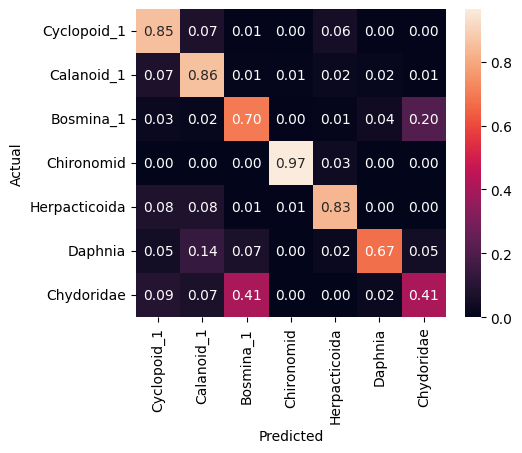

In [ ]:
confusion_mtx = metrics.confusion_matrix(predicts[1], predicts[0])
# Normalise
cmn = confusion_mtx.astype('float') / confusion_mtx.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cmn, annot=True, fmt='.2f', xticklabels=classes, yticklabels=classes)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show(block=False)

## Train CNN only model

In [ ]:
train_load = torch.utils.data.DataLoader(
    Zooplankton_dataset(train_overlap, train_connect, images),
    batch_size=8, shuffle=True
)
test_load = torch.utils.data.DataLoader(
    Zooplankton_dataset(test_overlap, test_connect, images),
    batch_size=8, shuffle=True
)

model2 = zooplankton_classifier_CNN(len(col_features), len(dataset.classes)).to(device)

In [ ]:
optimizer = torch.optim.SGD([{'params': model2.parameters(), 'lr': lr, 'momentum': 0.9, 'nesterov': True}])
sched = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, lr, epochs=epochs, steps_per_epoch=len(train_load), pct_start=1./float(epochs)
)
train_acc, test_acc, elapsed = train(
    model2, optimizer, train_load, test_load, epochs=epochs,
    clip_norm=clip_norm, sched=sched, train_weight=torch.tensor(train_weight).to(device)
)

test 10 loss=0.6889 acc=0.7791: 100%|██████████| 47/47 [00:17<00:00,  2.74it/s]


In [ ]:
model2.eval()
test_acc, test_loss, predicts = test_epoch(0, model2, test_load, return_predicts=True)

test 0 loss=0.6606 acc=0.783: 100%|██████████| 47/47 [00:13<00:00,  3.43it/s]


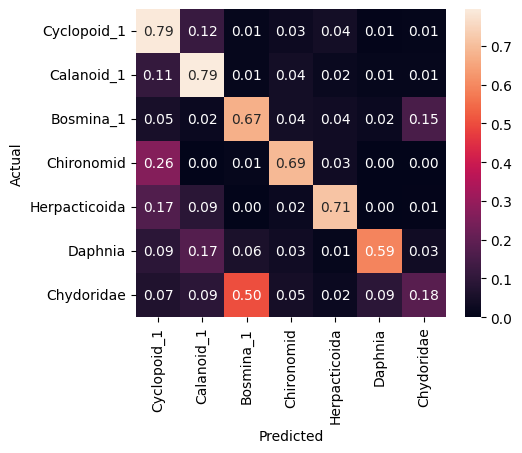

In [ ]:
confusion_mtx = metrics.confusion_matrix(predicts[1], predicts[0])
# Normalise
cmn = confusion_mtx.astype('float') / confusion_mtx.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cmn, annot=True, fmt='.2f', xticklabels=classes, yticklabels=classes)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show(block=False)

## Train features only model

In [ ]:
train_load = torch.utils.data.DataLoader(
    Zooplankton_dataset(train_overlap, train_connect, images),
    batch_size=8, shuffle=True
)
test_load = torch.utils.data.DataLoader(
    Zooplankton_dataset(test_overlap, test_connect, images),
    batch_size=8, shuffle=True
)

model3 = zooplankton_classifier_features(len(col_features), len(dataset.classes)).to(device)

In [ ]:
optimizer = torch.optim.SGD([{'params': model3.parameters(), 'lr': lr, 'momentum': 0.9, 'nesterov': True}])
sched = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, lr, epochs=epochs, steps_per_epoch=len(train_load), pct_start=1./float(epochs)
)
train_acc, test_acc, elapsed = train(
    model3, optimizer, train_load, test_load, epochs=epochs,
    clip_norm=clip_norm, sched=sched, train_weight=torch.tensor(train_weight).to(device)
)

test 20 loss=0.4736 acc=0.854: 100%|██████████| 47/47 [00:02<00:00, 16.33it/s]


In [ ]:
model3.eval()
test_acc, test_loss, predicts = test_epoch(0, model3, test_load, return_predicts=True)

test 0 loss=0.5075 acc=0.8521: 100%|██████████| 47/47 [00:02<00:00, 15.87it/s]


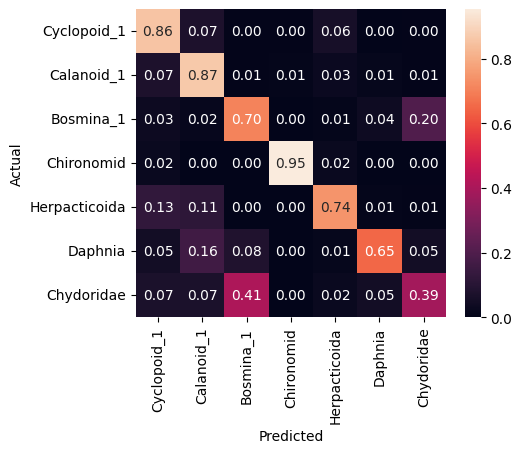

In [ ]:
confusion_mtx = metrics.confusion_matrix(predicts[1], predicts[0])
# Normalise
cmn = confusion_mtx.astype('float') / confusion_mtx.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cmn, annot=True, fmt='.2f', xticklabels=classes, yticklabels=classes)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show(block=False)